Initiating Factor Diagnostic... Analyzing Time-Series Snapshots.


# Multi-Factor Correlation Diagnostic Report

### 1. Average Correlation Matrix (Precise Statistics)

,mkt_cap_score,value_score,leverage_score,quality_score,momentum,volatility,volume_ratio,rsi,breakout
breakout,-0.1478,0.1271,-0.0568,-0.0413,0.6837,-0.3284,0.2673,0.6330,1.0000
leverage_score,0.1717,-0.1624,1.0000,0.5530,-0.0003,0.1323,-0.0177,-0.0076,-0.0568
mkt_cap_score,1.0000,-0.1027,0.1717,-0.0054,-0.0692,0.2005,-0.0152,-0.0856,-0.1478
momentum,-0.0692,-0.0363,-0.0003,0.0032,1.0000,0.1183,0.2590,0.7284,0.6837
quality_score,-0.0054,-0.1033,0.5530,1.0000,0.0032,0.0848,-0.0063,0.0013,-0.0413
rsi,-0.0856,-0.0420,-0.0076,0.0013,0.7284,0.1703,0.1466,1.0000,0.6330
value_score,-0.1027,1.0000,-0.1624,-0.1033,-0.0363,-0.3431,0.0120,-0.0420,0.1271
volatility,0.2005,-0.3431,0.1323,0.0848,0.1183,1.0000,-0.0366,0.1703,-0.3284
volume_ratio,-0.0152,0.0120,-0.0177,-0.0063,0.2590,-0.0366,1.0000,0.1466,0.2673


### 2. 🔴 Redundancy Alert (Significant Overlap > 0.6)

,Factor A,Factor B,Corr_Coefficient
0,leverage_score,leverage_score,1.0000
1,breakout,breakout,1.0000
2,rsi,rsi,1.0000
3,momentum,momentum,1.0000
4,rsi,momentum,0.7284
5,breakout,momentum,0.6837
6,momentum,breakout,0.6837
7,breakout,rsi,0.6330
8,rsi,breakout,0.6330


### 3. 🟢 Diversification Pairs (Ideal for Multi-Factor Blending)

,Factor A,Factor B,Corr_Coefficient
0,volatility,quality_score,0.0848
1,rsi,quality_score,0.0013
2,momentum,leverage_score,-0.0003
3,quality_score,mkt_cap_score,-0.0054
4,volume_ratio,quality_score,-0.0063
5,rsi,leverage_score,-0.0076
6,volume_ratio,mkt_cap_score,-0.0152
7,volume_ratio,leverage_score,-0.0177
8,quality_score,breakout,-0.0413
9,breakout,quality_score,-0.0413


### 4. Visual Analysis & Clustering

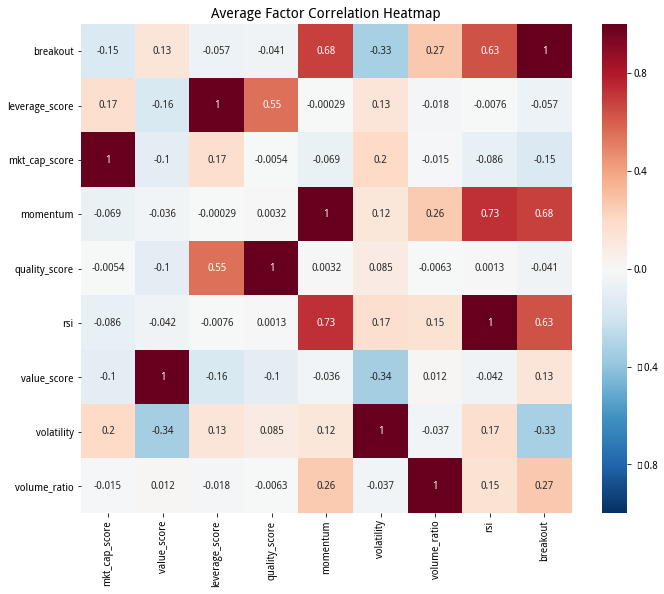

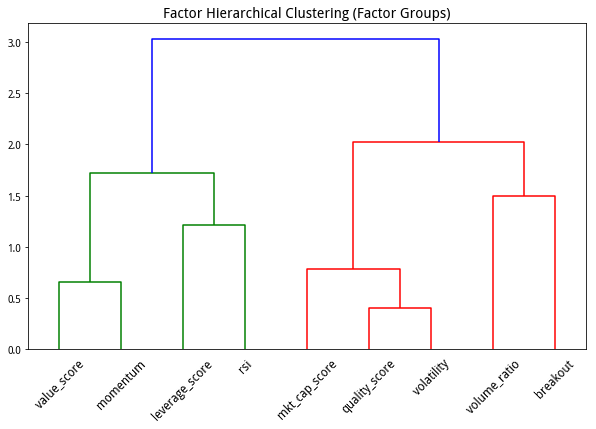

### 5. Rolling Correlation Stability (Momentum vs Volatility)

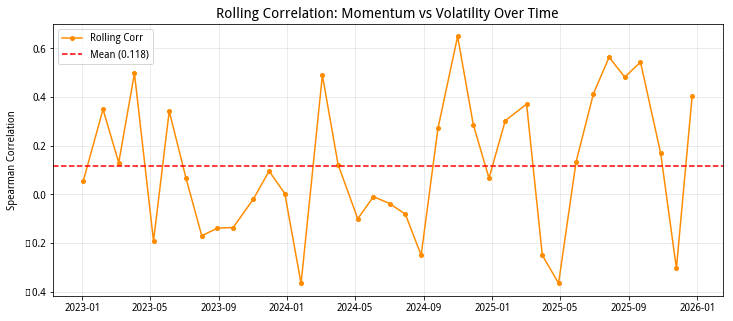

In [13]:
"""
================================================================================
QUANTITATIVE FACTOR CORRELATION DIAGNOSTIC TOOL
Description:
    This script performs a comprehensive multi-factor correlation analysis 
    within the JoinQuant Research Environment. It evaluates 9 distinct alpha 
    factors across fundamental, technical, and risk domains.

Key Features:
    1. Robust Preprocessing: MAD Winsorization and Z-Score standardization.
    2. Multi-Dimensional Output: Statistical tables, heatmaps, and dendrograms.
    3. Redundancy Alerts: Automatically flags factors with high collinearity.
    4. Time-Series Stability: Tracks how factor relationships evolve over time.
"""

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from jqdata import *
import scipy.cluster.hierarchy as sch
from IPython.display import display, Markdown
import warnings

# Suppress environment warnings for a clean report
warnings.filterwarnings('ignore')

# --- 1. CONFIGURATION ---
UNIVERSE = get_index_stocks('000300.XSHG') # CSI 300 stocks
START_DATE = '2023-01-01'
END_DATE = '2025-12-31'

# Generate sampling dates (every 20 trading days)
trading_days = get_trade_days(START_DATE, END_DATE)
sample_dates = trading_days[::20]

# --- 2. FACTOR CALCULATION ENGINE ---
def calculate_alpha_factors(stocks, date):
    """
    Calculates 9 alpha factors for a specific list of stocks on a specific date.
    """
    # I. Fetch Fundamental Data (Fundamental Factors)
    q = query(
        valuation.code,
        valuation.market_cap,         
        valuation.pe_ratio,           
        balance.total_liability,      
        balance.total_assets,         
        indicator.gross_profit_margin 
    ).filter(valuation.code.in_(stocks))
    df_fund = get_fundamentals(q, date)
    
    if df_fund.empty:
        return pd.DataFrame()
    
    df_fund.set_index('code', inplace=True)

    # Fundamental Factor Definitions
    # 1. Market Cap Score (Small-cap bias via negative log)
    df_fund['mkt_cap_score'] = -np.log(df_fund['market_cap'])
    # 2. Value Score (Earnings Yield = 1/PE)
    df_fund['value_score'] = 1.0 / df_fund['pe_ratio'].replace(0, np.nan)
    # 3. Leverage Score (Inverse Debt-to-Asset ratio)
    df_fund['leverage_score'] = -(df_fund['total_liability'] / df_fund['total_assets'])
    # 4. Quality Score (Gross Profit Margin)
    df_fund['quality_score'] = df_fund['gross_profit_margin']

    # II. Fetch Price Data (Technical Factors)
    # Fetch 31 days to ensure a 20-day calculation window is possible
    h = get_price(stocks, end_date=date, frequency='daily', 
                  fields=['close', 'volume', 'high', 'low'], 
                  count=31, panel=False)
    
    if h.empty:
        return pd.DataFrame()

    # Pivot data into matrices (Time x Ticker)
    close_px = h.pivot(index='time', columns='code', values='close')
    vol_data = h.pivot(index='time', columns='code', values='volume')
    high_px = h.pivot(index='time', columns='code', values='high')

    # 5. Price Momentum (20-day percentage return)
    mom = close_px.iloc[-1] / close_px.iloc[-20] - 1
    # 6. Volatility (20-day standard deviation of daily returns)
    vol = close_px.pct_change().std()
    # 7. Volume Ratio (Last 5-day Avg Vol / 20-day Avg Vol)
    v_ratio = vol_data.iloc[-5:].mean() / vol_data.mean()
    # 8. RSI (Relative Strength Index - Simplified 20-day)
    diff = close_px.diff()
    up = diff.where(diff > 0, 0).sum()
    down = diff.where(diff < 0, 0).abs().sum()
    rsi = up / (up + down + 1e-5)
    # 9. Breakout (Current Price / 20-day high)
    breakout = close_px.iloc[-1] / high_px.iloc[:-1].max()

    tech_df = pd.DataFrame({
        'momentum': mom,
        'volatility': vol,
        'volume_ratio': v_ratio,
        'rsi': rsi,
        'breakout': breakout
    })
    
    # Inner join Fundamental and Technical dataframes
    final = pd.concat([
        df_fund[['mkt_cap_score', 'value_score', 'leverage_score', 'quality_score']], 
        tech_df
    ], axis=1, join='inner')
    
    return final.dropna()

# --- 3. EXECUTION LOOP ---
correlation_history = []
valid_dates = [] # Track dates that actually produced data to avoid shape errors

print("Initiating Factor Diagnostic... Analyzing Time-Series Snapshots.")

for dt in sample_dates:
    factors = calculate_alpha_factors(UNIVERSE, dt)
    
    if not factors.empty:
        # Preprocessing: MAD Winsorization for Outlier Mitigation
        for col in factors.columns:
            median = factors[col].median()
            mad = (factors[col] - median).abs().median()
            # Clip values to [Median +/- 3*MAD]
            factors[col] = np.clip(factors[col], median - 4.4478 * mad, median + 4.4478 * mad)
        
        # Calculate Spearman Rank Correlation (more robust than Pearson)
        corr_matrix = factors.corr(method='spearman')
        correlation_history.append(corr_matrix)
        valid_dates.append(dt)
    else:
        print(f"Skipping {dt}: Data unavailable.")

# --- 4. ANALYTICAL REPORT & VISUALIZATION ---
if correlation_history:
    # A. Aggregate Data
    avg_corr = pd.concat(correlation_history).groupby(level=0).mean()
    
    # B. Professional Markdown Report
    display(Markdown("# Multi-Factor Correlation Diagnostic Report"))
    
    display(Markdown("### 1. Average Correlation Matrix (Precise Statistics)"))
    display(avg_corr.round(4))
    
    # C. Redundancy Alert (Auto-scanning for collinearity > 0.6)
    display(Markdown("### 2. 🔴 Redundancy Alert (Significant Overlap > 0.6)"))
    mask = np.triu(np.ones(avg_corr.shape), k=1).astype(bool)
    corr_stack = avg_corr.where(mask).unstack().dropna().sort_values(ascending=False)
    high_corr = corr_stack[corr_stack > 0.6].reset_index()
    high_corr.columns = ['Factor A', 'Factor B', 'Corr_Coefficient']
    if not high_corr.empty:
        display(high_corr.round(4))
    else:
        display(Markdown("*No significant redundancy detected in the factor pool.*"))

    # D. Diversification Recommendation (Correlation < 0.1)
    display(Markdown("### 3. 🟢 Diversification Pairs (Ideal for Multi-Factor Blending)"))
    low_corr = corr_stack[abs(corr_stack) < 0.1].reset_index()
    low_corr.columns = ['Factor A', 'Factor B', 'Corr_Coefficient']
    display(low_corr.head(10).round(4))

    # E. Visual Mapping
    display(Markdown("### 4. Visual Analysis & Clustering"))
    
    # Heatmap
    plt.figure(figsize=(11, 9))
    sns.heatmap(avg_corr, cmap='RdBu_r', annot=True, center=0, vmin=-1, vmax=1)
    plt.title('Average Factor Correlation Heatmap', fontsize=14)
    plt.show()

    # Dendrogram for Cluster Analysis
    plt.figure(figsize=(10, 6))
    dist = sch.distance.pdist(avg_corr.values)
    link = sch.linkage(dist, method='ward')
    sch.dendrogram(link, labels=avg_corr.columns)
    plt.title('Factor Hierarchical Clustering (Factor Groups)', fontsize=14)
    plt.xticks(rotation=45)
    plt.show()

    # F. Time-Series Stability (Fixing the previous shape error)
    display(Markdown("### 5. Rolling Correlation Stability (Momentum vs Volatility)"))
    ts_corr = [c.loc['momentum', 'volatility'] for c in correlation_history]
    
    plt.figure(figsize=(12, 5))
    plt.plot(valid_dates, ts_corr, marker='o', markersize=4, linestyle='-', color='darkorange', label='Rolling Corr')
    plt.axhline(np.mean(ts_corr), color='red', linestyle='--', label=f'Mean ({np.mean(ts_corr):.3f})')
    plt.title('Rolling Correlation: Momentum vs Volatility Over Time', fontsize=14)
    plt.ylabel('Spearman Correlation')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

else:
    print("Critical Error: No data processed. Please check your index code or date range.")

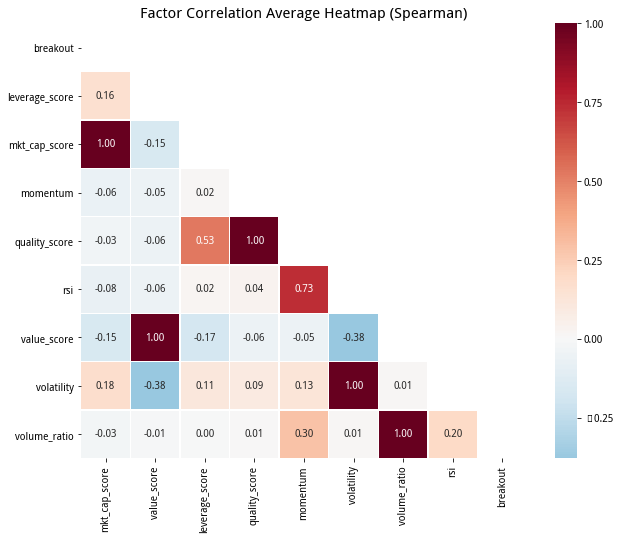

In [10]:
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(avg_corr, dtype=bool)) 
sns.heatmap(avg_corr, mask=mask, cmap='RdBu_r', center=0, annot=True, fmt='.2f', linewidths=0.5)
plt.title('Factor Correlation Average Heatmap (Spearman)', fontsize=15)
plt.show()

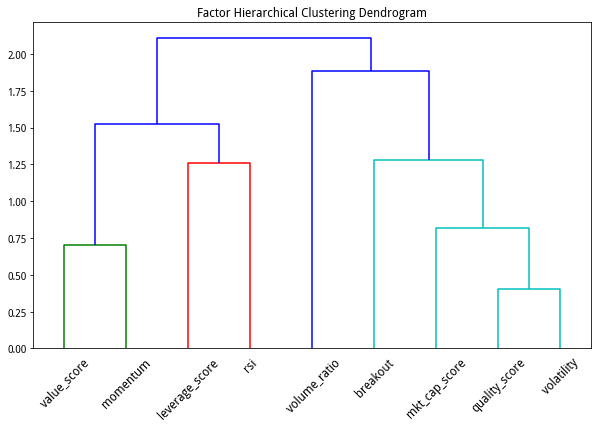

In [11]:
plt.figure(figsize=(10, 6))
d = sch.distance.pdist(avg_corr.values)
L = sch.linkage(d, method='complete')
sch.dendrogram(L, labels=avg_corr.columns)
plt.title('Factor Hierarchical Clustering Dendrogram')
plt.xticks(rotation=45)
plt.show()